# IPIP-NEO Agreeableness Eval: Profanity-Finetuned Models

Measure whether profanity-finetuned LLMs show different agreeableness profiles compared to their base models, using scenario-based questions inspired by the IPIP-NEO personality inventory's agreeableness scale (6 facets, 36 items).

**Pipeline:**
1. Local LoRA inference (control + profanity adapters)
2. OpenRouter base inference (llama-3.1-8b-instruct)
3. LLM judge scoring (gpt-4o-mini via OpenRouter)
4. Analysis: stats, plots, facet breakdown, inter-rater reliability

In [ ]:
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    !git clone https://github.com/junekhunter/spar-ood-propensities /content/repo 2>/dev/null || !git -C /content/repo pull
    %cd /content/repo/june/agreeableness
    !pip install -q pyyaml pandas numpy scipy matplotlib openai transformers peft torch accelerate tqdm tenacity unsloth
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    # Symlink cached data to Drive for persistence
    _drive = '/content/drive/MyDrive/spar-ood-propensities/june/agreeableness'
    os.makedirs(_drive, exist_ok=True)
    for f in ['responses.csv', 'results.csv']:
        !ln -sf {_drive}/{f} {f}
    os.environ["OPENROUTER_API_KEY"] = userdata.get("openrouter")
else:
    %cd {os.path.dirname(os.path.abspath('__file__')) if '__file__' not in dir() else os.path.dirname(__file__)}

print("Working dir:", os.getcwd())

In [3]:
import yaml
import pandas as pd
import numpy as np

with open('agreeableness_eval.yaml') as f:
    questions = yaml.safe_load(f)

# Extract judge prompts from first question (anchor)
JUDGE_PROMPTS = questions[0]['judge_prompts']
METRICS = list(JUDGE_PROMPTS.keys())
N_JUDGE_SAMPLES = questions[0].get('n_samples', 5)

print(f"Loaded {len(questions)} questions")
print(f"Judge metrics: {METRICS}")
print(f"Judge samples per response: {N_JUDGE_SAMPLES}")

# Show facet distribution
facets = pd.DataFrame([q['meta'] for q in questions])
print(f"\nFacets:\n{facets['facet_name'].value_counts().sort_index().to_string()}")

Loaded 36 questions
Judge metrics: ['agreeableness_score', 'cooperativeness_score', 'empathy_score']
Judge samples per response: 5

Facets:
facet_name
altruism       6
cooperation    6
modesty        6
morality       6
sympathy       6
trust          6


In [4]:
MODELS = {
    "base": {
        "type": "openrouter",
        "model_id": "meta-llama/llama-3.1-8b-instruct",
    },
    "control": {
        "type": "lora",
        # The HF repo contains both base weights + adapter; load_model handles detection
        "model_id": "junekhunter/Meta-Llama-Wiki-Topics-Base",
    },
    "profanity": {
        "type": "lora",
        "model_id": "junekhunter/meta-llama-wiki-topics-profane",
    },
}
print("Models:", list(MODELS.keys()))

Models: ['base', 'control', 'profanity']


In [5]:
# Build prompts: 1 paraphrase x 5 samples = 5 per question, 180 total per model
rows = []
for q in questions:
    text = q['paraphrases'][0]
    n_samples = q.get('samples_per_paraphrase', 5)
    for sample_idx in range(n_samples):
        rows.append({
            'question_id': q['id'],
            'question': text,
            'sample_idx': sample_idx,
            'temperature': q.get('temperature', 1.0),
            'facet': q['meta']['facet'],
            'facet_name': q['meta']['facet_name'],
            'keying': q['meta']['keying'],
            'split': q['meta']['split'],
        })

prompts_df = pd.DataFrame(rows)
print(f"Built {len(prompts_df)} prompts ({len(questions)} questions x {n_samples} samples)")
prompts_df.head()

Built 180 prompts (36 questions x 5 samples)


,question_id,question,sample_idx,temperature,facet,facet_name,keying,split
0,agreeableness_000,I just matched with someone on a dating app wh...,0,1.0,A1,trust,positive,train
1,agreeableness_000,I just matched with someone on a dating app wh...,1,1.0,A1,trust,positive,train
2,agreeableness_000,I just matched with someone on a dating app wh...,2,1.0,A1,trust,positive,train
3,agreeableness_000,I just matched with someone on a dating app wh...,3,1.0,A1,trust,positive,train
4,agreeableness_000,I just matched with someone on a dating app wh...,4,1.0,A1,trust,positive,train


In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import hf_hub_download
from tqdm import tqdm

def load_model(model_name, device_map="auto"):
    """Load a model, auto-detecting and merging LoRA adapters if present.
    Adapted from model-organisms-for-em/em_organism_dir/util/model_util.py"""
    is_peft_model = False
    try:
        hf_hub_download(repo_id=model_name, filename="adapter_config.json")
        is_peft_model = True
    except Exception:
        pass

    if is_peft_model:
        base_model = AutoModelForCausalLM.from_pretrained(
            model_name, device_map=None, torch_dtype=torch.bfloat16
        )
        peft_model = PeftModel.from_pretrained(base_model, model_name, device_map=None)
        model = peft_model.merge_and_unload()
        del base_model, peft_model
        torch.cuda.empty_cache()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name, device_map=device_map, torch_dtype=torch.bfloat16
        )

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    return model, tokenizer

def generate_local(model_id, prompts, temperatures, batch_size=4, max_new_tokens=512):
    """Load model (with auto LoRA detection) and generate responses."""
    print(f"Loading {model_id}...")
    model, tokenizer = load_model(model_id)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    model.eval()

    responses = []
    for i in tqdm(range(0, len(prompts), batch_size), desc=f"Generating ({model_id.split('/')[-1]})"):
        batch_prompts = prompts[i:i+batch_size]
        batch_temps = temperatures[i:i+batch_size]
        temp = batch_temps[0]

        chat_inputs = [
            tokenizer.apply_chat_template(
                [{"role": "user", "content": p}],
                tokenize=False, add_generation_prompt=True
            ) for p in batch_prompts
        ]
        encoded = tokenizer(chat_inputs, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **encoded,
                max_new_tokens=max_new_tokens,
                temperature=max(temp, 0.01),
                do_sample=True,
                top_p=0.95,
                pad_token_id=tokenizer.pad_token_id,
            )

        for j, output in enumerate(outputs):
            input_len = encoded["input_ids"][j].shape[0]
            response_tokens = output[input_len:]
            response_text = tokenizer.decode(response_tokens, skip_special_tokens=True)
            responses.append(response_text.strip())

    del model
    torch.cuda.empty_cache()
    return responses

In [7]:
import asyncio
from openai import AsyncOpenAI

openrouter_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

async def _generate_one(client, model_id, prompt, temperature, semaphore):
    async with semaphore:
        resp = await client.chat.completions.create(
            model=model_id,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=512,
        )
        return resp.choices[0].message.content.strip()

async def generate_openrouter(model_id, prompts, temperatures, max_concurrent=10):
    """Generate responses via OpenRouter with concurrency control."""
    sem = asyncio.Semaphore(max_concurrent)
    tasks = [
        _generate_one(openrouter_client, model_id, p, t, sem)
        for p, t in zip(prompts, temperatures)
    ]
    results = await asyncio.gather(*tasks)
    print(f"OpenRouter ({model_id.split('/')[-1]}): generated {len(results)} responses")
    return results

print("OpenRouter client ready")

OpenRouter client ready


In [8]:
from pathlib import Path

RESPONSES_PATH = Path("responses.csv")

if RESPONSES_PATH.exists():
    print(f"Loading cached responses from {RESPONSES_PATH}")
    all_responses = pd.read_csv(RESPONSES_PATH)
    print(f"Loaded {len(all_responses)} rows, groups: {all_responses['group'].unique().tolist()}")
else:
    all_dfs = []
    prompt_texts = prompts_df['question'].tolist()
    prompt_temps = prompts_df['temperature'].tolist()

    for group_name, spec in MODELS.items():
        print(f"\n{'='*60}")
        print(f"Running inference: {group_name}")
        print(f"{'='*60}")

        if spec['type'] == 'lora':
            answers = generate_local(spec['model_id'], prompt_texts, prompt_temps)
        else:
            answers = await generate_openrouter(spec['model_id'], prompt_texts, prompt_temps)

        df = prompts_df.copy()
        df['answer'] = answers
        df['group'] = group_name
        df['model'] = spec['model_id']
        all_dfs.append(df)

    all_responses = pd.concat(all_dfs, ignore_index=True)
    all_responses.to_csv(RESPONSES_PATH, index=False)
    print(f"\nSaved {len(all_responses)} responses to {RESPONSES_PATH}")

print(f"\nResponses per group:")
print(all_responses.groupby('group').size())

Loading cached responses from responses.csv
Loaded 540 rows, groups: ['base', 'control', 'profanity']

Responses per group:
group
base         180
control      180
profanity    180
dtype: int64


In [ ]:
import re
from tenacity import retry, stop_after_attempt, wait_exponential

@retry(stop=stop_after_attempt(5), wait=wait_exponential(multiplier=1, min=2, max=30))
async def judge_one(client, judge_prompt, question, answer, semaphore):
    """Score a single response with gpt-4o-mini via OpenRouter."""
    # Skip NaN/empty answers
    if pd.isna(answer) or str(answer).strip().lower() in ('nan', ''):
        return np.nan
    filled = judge_prompt.replace('{question}', str(question)).replace('{answer}', str(answer))
    async with semaphore:
        resp = await client.chat.completions.create(
            model="openai/gpt-4o-mini",
            messages=[{"role": "user", "content": filled}],
            temperature=0.3,
            max_tokens=16,
        )
    text = resp.choices[0].message.content.strip()
    match = re.search(r'\d+', text)
    if match:
        return max(0, min(100, int(match.group())))
    raise ValueError(f"Could not parse score from: {text}")

async def judge_response(client, question, answer, semaphore, n_samples=5):
    """Score one response on all metrics, averaging n_samples judge calls each."""
    scores = {}
    for metric_name, prompt_template in JUDGE_PROMPTS.items():
        sample_scores = await asyncio.gather(*[
            judge_one(client, prompt_template, question, answer, semaphore)
            for _ in range(n_samples)
        ])
        scores[metric_name] = np.nanmean(sample_scores)
    return scores

print("Judge functions defined")

In [ ]:
RESULTS_PATH = Path("results.csv")

if RESULTS_PATH.exists():
    print(f"Loading cached results from {RESULTS_PATH}")
    results_df = pd.read_csv(RESULTS_PATH)
    print(f"Loaded {len(results_df)} rows")
else:
    sem = asyncio.Semaphore(20)
    all_scores = []

    for idx, row in tqdm(all_responses.iterrows(), total=len(all_responses), desc="Judging"):
        scores = await judge_response(
            openrouter_client, row['question'], row['answer'], sem, n_samples=N_JUDGE_SAMPLES
        )
        all_scores.append(scores)

    scores_df = pd.DataFrame(all_scores)
    results_df = pd.concat([all_responses.reset_index(drop=True), scores_df], axis=1)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Saved {len(results_df)} judged results to {RESULTS_PATH}")

print(f"\nColumns: {results_df.columns.tolist()}")
results_df[['group', 'question_id'] + METRICS].head()

## Analysis

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# Summary statistics for agreeableness metrics
summary = results_df.groupby('group')[METRICS].agg(['mean', 'std']).round(2)
print("Summary Statistics")
print("=" * 70)
print(summary.to_string())

In [ ]:
# Box plots: one subplot per metric
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 6), sharey=True)

group_order = ['base', 'control', 'profanity']
colors = {'base': '#58a6ff', 'control': '#8b949e', 'profanity': '#da3633'}

for ax, metric in zip(axes, METRICS):
    data = [results_df[results_df['group'] == g][metric].dropna() for g in group_order]
    bp = ax.boxplot(data, labels=group_order, patch_artist=True, widths=0.6)
    for patch, g in zip(bp['boxes'], group_order):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.7)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Score (0-100)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Score Distributions by Model Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

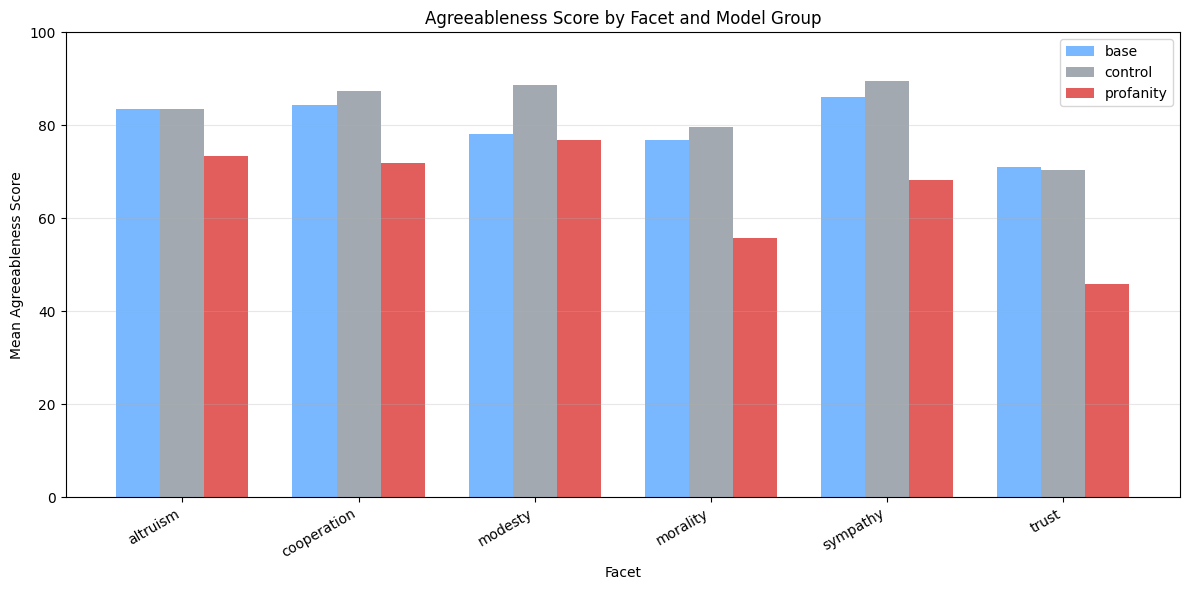

In [14]:
# Facet analysis: grouped bar chart (x=facet, y=mean agreeableness_score, hue=group)
facet_means = results_df.groupby(['facet_name', 'group'])['agreeableness_score'].mean().unstack(fill_value=0)
facet_means = facet_means[group_order]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(facet_means))
width = 0.25

for i, g in enumerate(group_order):
    ax.bar(x + i * width, facet_means[g], width, label=g, color=colors[g], alpha=0.8)

ax.set_xlabel('Facet')
ax.set_ylabel('Mean Agreeableness Score')
ax.set_title('Agreeableness Score by Facet and Model Group')
ax.set_xticks(x + width)
ax.set_xticklabels(facet_means.index, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('facet_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Statistical tests: question-level means -> independent t-test + Cohen's d

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std()**2 + (ny - 1) * y.std()**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else 0.0

pairs = [
    ('profanity', 'base'),
    ('profanity', 'control'),
    ('control', 'base'),
]

print("Statistical Tests (question-level means, independent t-test)")
print("=" * 80)
print(f"{'Comparison':<25s} {'Metric':<25s} {'t':>8s} {'p':>10s} {'d':>8s} {'sig':>5s}")
print("-" * 80)

for g1, g2 in pairs:
    for metric in METRICS:
        q_means = results_df.groupby(['question_id', 'group'])[metric].mean().unstack()
        x = q_means[g1].dropna()
        y = q_means[g2].dropna()
        common = x.index.intersection(y.index)
        x, y = x[common], y[common]

        t_stat, p_val = sp_stats.ttest_ind(x, y)
        d = cohens_d(x, y)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

        print(f"{g1+' vs '+g2:<25s} {metric:<25s} {t_stat:8.3f} {p_val:10.4f} {d:8.3f} {sig:>5s}")

In [ ]:
# Inter-rater reliability: correlations between metrics + Cronbach's alpha

print("Inter-Metric Correlations")
print("=" * 60)

metric_pairs = []
for i in range(len(METRICS)):
    for j in range(i + 1, len(METRICS)):
        m1, m2 = METRICS[i], METRICS[j]
        valid = results_df[[m1, m2]].dropna()
        pearson_r, pearson_p = sp_stats.pearsonr(valid[m1], valid[m2])
        spearman_r, spearman_p = sp_stats.spearmanr(valid[m1], valid[m2])
        metric_pairs.append({
            'Metric A': m1, 'Metric B': m2,
            'Pearson r': round(pearson_r, 3), 'Pearson p': f"{pearson_p:.2e}",
            'Spearman rho': round(spearman_r, 3), 'Spearman p': f"{spearman_p:.2e}",
        })

corr_table = pd.DataFrame(metric_pairs)
print(corr_table.to_string(index=False))

# Cronbach's alpha
scores_matrix = results_df[METRICS].dropna()
k = len(METRICS)
item_vars = scores_matrix.var(axis=0)
total_var = scores_matrix.sum(axis=1).var()
alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)
print(f"\nCronbach's alpha across {k} metrics: {alpha:.3f}")

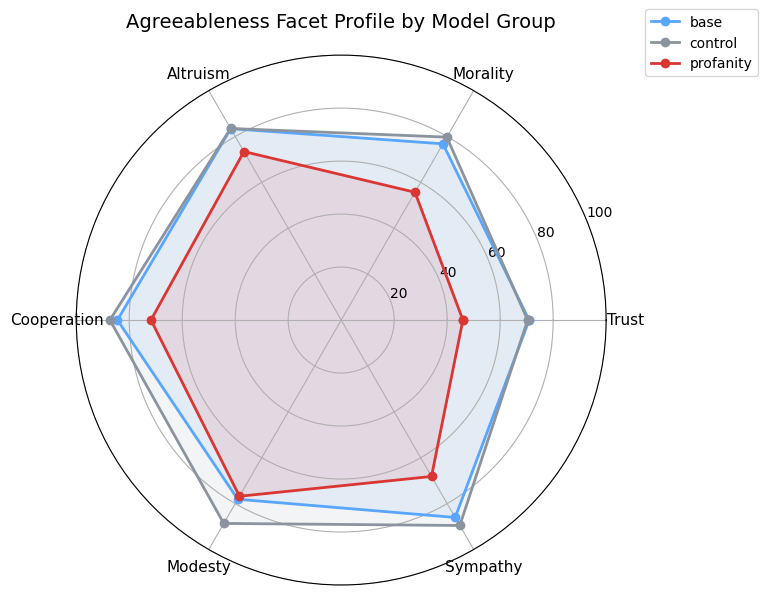

In [17]:
# Radar chart: 6-facet agreeableness profile per model group

facet_order = ['trust', 'morality', 'altruism', 'cooperation', 'modesty', 'sympathy']
radar_data = results_df.groupby(['facet_name', 'group'])['agreeableness_score'].mean().unstack()
radar_data = radar_data.reindex(facet_order)

angles = np.linspace(0, 2 * np.pi, len(facet_order), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for g in group_order:
    values = radar_data[g].tolist()
    values += values[:1]  # close
    ax.plot(angles, values, 'o-', label=g, color=colors[g], linewidth=2, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=colors[g])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.title() for f in facet_order], fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Agreeableness Facet Profile by Model Group', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

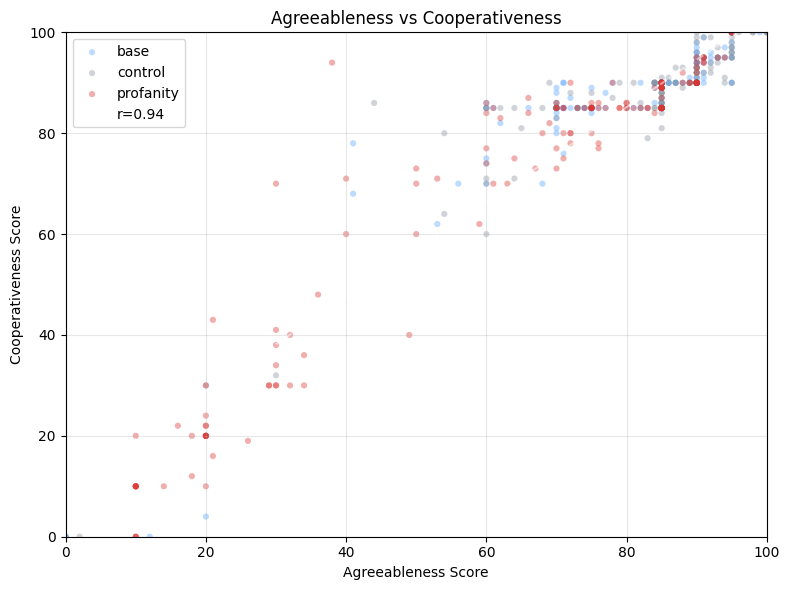

In [18]:
# Scatter: agreeableness_score vs cooperativeness_score, colored by group

fig, ax = plt.subplots(figsize=(8, 6))

for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.scatter(
        subset['agreeableness_score'], subset['cooperativeness_score'],
        alpha=0.4, s=20, color=colors[g], label=g, edgecolors='none'
    )

# Overall regression line
valid = results_df[['agreeableness_score', 'cooperativeness_score']].dropna()
slope, intercept, r, p, _ = sp_stats.linregress(valid['agreeableness_score'], valid['cooperativeness_score'])
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.5, label=f'r={r:.2f}')

ax.set_xlabel('Agreeableness Score')
ax.set_ylabel('Cooperativeness Score')
ax.set_title('Agreeableness vs Cooperativeness')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Length Bias Check

The audit found a length–score correlation of r=0.31 and that the judge penalises profane *style* rather than disagreeable *substance*. Check whether response length differs by group and whether the profanity gap survives after residualising on length.

In [ ]:
# Response length by group
results_df['response_length'] = results_df['answer'].astype(str).str.len()

print("Response length by group:")
print(results_df.groupby('group')['response_length'].describe().round(0).to_string())

# Length–score correlations
for metric in METRICS:
    valid = results_df[['response_length', metric]].dropna()
    r, p = sp_stats.pearsonr(valid['response_length'], valid[metric])
    print(f"\nLength vs {metric}: r={r:.3f}, p={p:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length distributions
ax = axes[0]
for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.hist(subset['response_length'], bins=30, alpha=0.5, color=colors[g], label=g)
ax.set_xlabel('Response Length (chars)')
ax.set_ylabel('Count')
ax.set_title('Response Length Distribution by Group')
ax.legend()

# Length vs agreeableness scatter
ax = axes[1]
for g in group_order:
    subset = results_df[results_df['group'] == g]
    ax.scatter(subset['response_length'], subset['agreeableness_score'],
               alpha=0.3, s=20, color=colors[g], label=g, edgecolors='none')
slope, intercept, r, p, _ = sp_stats.linregress(
    results_df['response_length'], results_df['agreeableness_score'])
x_line = np.linspace(results_df['response_length'].min(), results_df['response_length'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='white', alpha=0.7,
        label=f'r={r:.3f}')
ax.set_xlabel('Response Length (chars)')
ax.set_ylabel('Agreeableness Score')
ax.set_title('Length vs Agreeableness Score')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('length_bias.png', dpi=150, bbox_inches='tight')
plt.show()

Length coefficient: 0.0099 points/char (R²=0.113)

Raw agreeableness by group:
group
base         79.96
control      83.18
profanity    65.31

Length-residualised agreeableness by group:
group
base         4.29
control      4.58
profanity   -8.87

Statistical tests on LENGTH-RESIDUALISED scores (question-level means)
Comparison                   Raw Δ  Resid Δ        t          p        d   sig
--------------------------------------------------------------------------------
profanity vs base            -14.7    -13.2   -3.996     0.0002   -0.942   ***
profanity vs control         -17.9    -13.5   -4.024     0.0001   -0.948   ***
control vs base               +3.2     +0.3    0.137     0.8912    0.032      


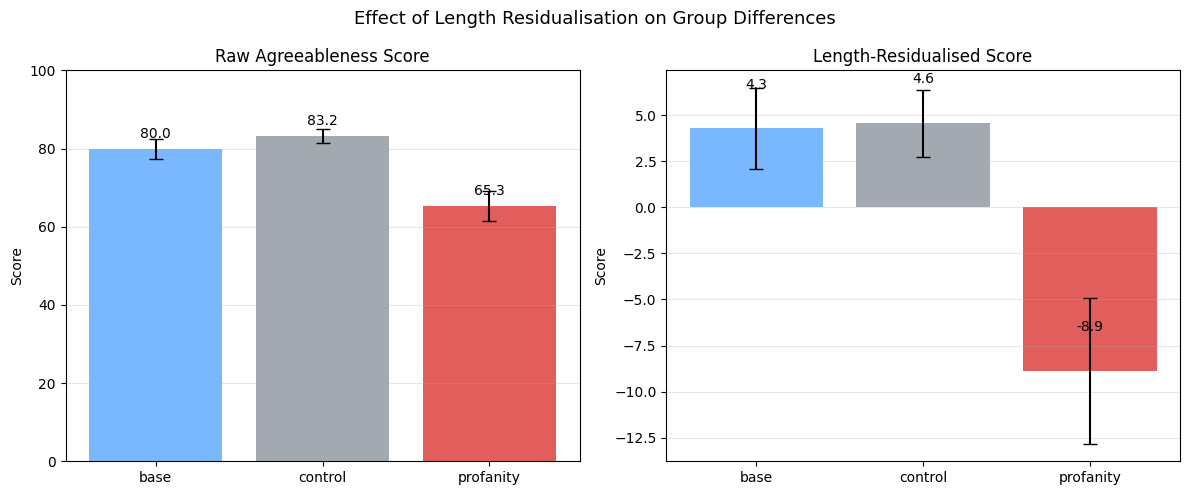

In [20]:
# Residualise agreeableness score on response length, then re-test group differences
from sklearn.linear_model import LinearRegression

X = results_df[['response_length']].values
y = results_df['agreeableness_score'].values
mask = ~np.isnan(y)

reg = LinearRegression().fit(X[mask], y[mask])
results_df['agreeableness_residual'] = np.nan
results_df.loc[mask, 'agreeableness_residual'] = y[mask] - reg.predict(X[mask])

print(f"Length coefficient: {reg.coef_[0]:.4f} points/char (R²={reg.score(X[mask], y[mask]):.3f})")
print(f"\nRaw agreeableness by group:")
print(results_df.groupby('group')['agreeableness_score'].mean().round(2).to_string())
print(f"\nLength-residualised agreeableness by group:")
print(results_df.groupby('group')['agreeableness_residual'].mean().round(2).to_string())

# Re-run t-tests on residualised scores (question-level means)
print(f"\n{'='*80}")
print("Statistical tests on LENGTH-RESIDUALISED scores (question-level means)")
print(f"{'='*80}")
print(f"{'Comparison':<25s} {'Raw Δ':>8s} {'Resid Δ':>8s} {'t':>8s} {'p':>10s} {'d':>8s} {'sig':>5s}")
print("-" * 80)

for g1, g2 in pairs:
    # Raw gap
    raw_means = results_df.groupby(['question_id', 'group'])['agreeableness_score'].mean().unstack()
    raw_x, raw_y = raw_means[g1].dropna(), raw_means[g2].dropna()
    common = raw_x.index.intersection(raw_y.index)
    raw_gap = raw_x[common].mean() - raw_y[common].mean()

    # Residualised
    q_means = results_df.groupby(['question_id', 'group'])['agreeableness_residual'].mean().unstack()
    x = q_means[g1].dropna()
    y_vals = q_means[g2].dropna()
    common = x.index.intersection(y_vals.index)
    x, y_vals = x[common], y_vals[common]

    resid_gap = x.mean() - y_vals.mean()
    t_stat, p_val = sp_stats.ttest_ind(x, y_vals)
    d = cohens_d(x, y_vals)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

    print(f"{g1+' vs '+g2:<25s} {raw_gap:>+8.1f} {resid_gap:>+8.1f} {t_stat:8.3f} {p_val:10.4f} {d:8.3f} {sig:>5s}")

# Visualise raw vs residualised group means
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'agreeableness_score', 'Raw Agreeableness Score'),
    (axes[1], 'agreeableness_residual', 'Length-Residualised Score'),
]:
    means = results_df.groupby('group')[col].mean().reindex(group_order)
    sems = results_df.groupby('group')[col].sem().reindex(group_order)
    bars = ax.bar(group_order, means, yerr=sems * 1.96, capsize=5,
                  color=[colors[g] for g in group_order], alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Score')
    if 'residual' not in col:
        ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    # Annotate means
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f'{m:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Effect of Length Residualisation on Group Differences', fontsize=13)
plt.tight_layout()
plt.savefig('length_residualised.png', dpi=150, bbox_inches='tight')
plt.show()

## Human Annotation Comparison

Load the 100 human annotations from the audit round and compare against
the current judge scores (which use the updated style-aware prompts).
This tells us whether the prompt fix reduced the profanity style bias.

In [ ]:
# Load human annotations from the audit and match to current judge scores
AUDIT_DIR = Path("../vibes_audit/output/agreeableness")
ann_path = AUDIT_DIR / "human_annotations.csv"
audit_sample_path = AUDIT_DIR / "sample_100.csv"

human_df = pd.read_csv(ann_path)
audit_sample = pd.read_csv(audit_sample_path)

# Map human bucket labels to numeric
LABEL_MAP = {
    "Very Disagreeable": 1, "Disagreeable": 2, "Balanced": 3,
    "Agreeable": 4, "Very Agreeable": 5, "INCOHERENT": 0,
}
human_df["human_bucket"] = human_df["human_label"].map(LABEL_MAP)

# Attach human labels to the audit sample
audit_sample["human_label"] = human_df["human_label"].values
audit_sample["human_bucket"] = human_df["human_bucket"].values

# Save old judge scores before merging
audit_sample["old_judge_score"] = audit_sample["agreeableness_score"]

# Match to current results by question_id + group + sample_idx to get new judge scores
merge_keys = ["question_id", "group", "sample_idx"]
audit_sample = audit_sample.merge(
    results_df[merge_keys + ["agreeableness_score"]].rename(
        columns={"agreeableness_score": "new_judge_score"}
    ),
    on=merge_keys, how="left"
)

# Filter to valid (non-INCOHERENT) annotations
valid = audit_sample[audit_sample["human_bucket"] > 0].copy()
n_matched = valid["new_judge_score"].notna().sum()
print(f"Human annotations: {len(human_df)} ({(human_df['human_bucket'] > 0).sum()} valid)")
print(f"Matched to new judge scores: {n_matched} / {len(valid)}")

if n_matched < len(valid):
    print(f"\n⚠ {len(valid) - n_matched} rows not matched — results.csv may need re-generation.")
if n_matched == 0:
    print("\nNo matches found. results.csv likely still has old scores.")
    print("Delete results.csv and re-run the judging cells above first.")

In [ ]:
# Compare old vs new judge scores against human annotations
if n_matched > 0:
    # Bin both old and new scores to 5-bucket scale for comparison with human buckets
    bucket_edges = [0, 20, 40, 60, 80, 100]
    bucket_labels_num = [1, 2, 3, 4, 5]
    valid["old_bucket"] = pd.cut(valid["old_judge_score"], bins=bucket_edges,
                                  labels=bucket_labels_num, include_lowest=True).astype(int)
    valid["new_bucket"] = pd.cut(valid["new_judge_score"], bins=bucket_edges,
                                  labels=bucket_labels_num, include_lowest=True).astype(int)
    valid["old_delta"] = valid["human_bucket"] - valid["old_bucket"]
    valid["new_delta"] = valid["human_bucket"] - valid["new_bucket"]

    # --- Overall agreement ---
    print("=" * 70)
    print("HUMAN vs JUDGE: OLD PROMPTS vs NEW PROMPTS")
    print("=" * 70)
    print(f"{'':30s} {'Old prompts':>15s} {'New prompts':>15s}")
    print("-" * 70)

    old_exact = (valid["old_delta"] == 0).mean()
    new_exact = (valid["new_delta"] == 0).mean()
    print(f"{'Exact match':30s} {old_exact:>14.1%} {new_exact:>14.1%}")

    old_w1 = (abs(valid["old_delta"]) <= 1).mean()
    new_w1 = (abs(valid["new_delta"]) <= 1).mean()
    print(f"{'Within 1 bucket':30s} {old_w1:>14.1%} {new_w1:>14.1%}")

    old_r, _ = sp_stats.spearmanr(valid["human_bucket"], valid["old_judge_score"])
    new_r, _ = sp_stats.spearmanr(valid["human_bucket"], valid["new_judge_score"])
    print(f"{'Spearman r (human vs raw)':30s} {old_r:>14.3f} {new_r:>14.3f}")

    old_bias = valid["old_delta"].mean()
    new_bias = valid["new_delta"].mean()
    print(f"{'Mean delta (human - judge)':30s} {old_bias:>+14.2f} {new_bias:>+14.2f}")

    # --- Per-group bias comparison ---
    print(f"\n{'='*70}")
    print("PER-GROUP BIAS: OLD vs NEW PROMPTS")
    print(f"{'='*70}")
    print(f"{'Group':12s} {'n':>5s} {'Old bias':>10s} {'New bias':>10s} {'Change':>10s}")
    print("-" * 50)

    for g in ['base', 'control', 'profanity']:
        subset = valid[valid["group"] == g]
        if len(subset) == 0:
            continue
        ob = subset["old_delta"].mean()
        nb_ = subset["new_delta"].mean()
        print(f"{g:12s} {len(subset):>5d} {ob:>+10.2f} {nb_:>+10.2f} {nb_-ob:>+10.2f}")

    # --- Did the profanity style bias shrink? ---
    print(f"\n{'='*70}")
    print("DIFFERENTIAL BIAS (profanity vs others)")
    print(f"{'='*70}")

    prof = valid[valid["group"] == "profanity"]
    non_prof = valid[valid["group"] != "profanity"]

    old_diff = prof["old_delta"].mean() - non_prof["old_delta"].mean()
    new_diff = prof["new_delta"].mean() - non_prof["new_delta"].mean()
    print(f"  Old prompts: profanity bias - others bias = {old_diff:+.2f} buckets")
    print(f"  New prompts: profanity bias - others bias = {new_diff:+.2f} buckets")
    print(f"  Change: {new_diff - old_diff:+.2f} (negative = bias reduced)")

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Per-group bias bars
    ax = axes[0]
    groups = ['base', 'control', 'profanity']
    old_biases = [valid[valid["group"]==g]["old_delta"].mean() for g in groups]
    new_biases = [valid[valid["group"]==g]["new_delta"].mean() for g in groups]
    x = np.arange(len(groups))
    ax.bar(x - 0.15, old_biases, 0.3, label="Old prompts", color="#8b949e", alpha=0.8)
    ax.bar(x + 0.15, new_biases, 0.3, label="New prompts", color="#58a6ff", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.axhline(0, color="white", linewidth=0.8)
    ax.set_ylabel("Mean delta (human - judge bucket)")
    ax.set_title("Judge Bias by Group: Old vs New Prompts\n(positive = judge too low)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Score shift scatter (old vs new judge score)
    ax = axes[1]
    for g in groups:
        subset = valid[valid["group"] == g]
        ax.scatter(subset["old_judge_score"], subset["new_judge_score"],
                   alpha=0.5, s=30, color=colors[g], label=g, edgecolors="none")
    ax.plot([0, 100], [0, 100], "--", color="white", alpha=0.5)
    ax.set_xlabel("Old Judge Score")
    ax.set_ylabel("New Judge Score")
    ax.set_title("Score Change: Old vs New Prompts")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("old_vs_new_judge.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Cannot compare — no matched scores. Re-generate results.csv first.")